# Домашнее задание №1. Pandas. numpy. Обработка данных

## Ф.И.О: Шарипов Артем Сергеевич, Б05-306

Домашнее задание состоит из **2**-х частей:
- **Первая часть** посвящена эффективной реализации функций подсчета расстояния с использованием библиотеки _numpy_.
- **Вторая часть** предполагает заполнение предложенного блокнота.

### Часть 0.
- Вписать Ваши ФИО в предложенное поле.


### Часть 1. (5 баллов)
- реализуйте функции для вычисления расстояния из модуля ``tasks`` с использованием _numpy_
- запрещается использовать циклы и конструкцию list comprehension
- запрещается использовать сторонние библиотеки (за исключением _numpy_)
- для проверки можете использовать приложенные unit-тесты
   - чтобы запустить их в консоли выполните:
      ``$ python -m unittest``

### Часть 2. (15 баллов)
- заполните предложенный блокнот кодом и ответами на вопросы, где это требуется

----------------------------------------

**На проверку требуется отправить zip архив, который будет содержать следующие файлы:**
 - модуль ``tasks.py`` с реализованными функциями
 - заполненный блокнот в формате ``.ipynb``
 - заполненный блокнот в формате ``.html`` **(в jupyter: File -> Save and Export Notebook As -> HTML -> ...)**
 - файл ``answer.csv``, который получится в результате работы над блокнотом

### Часть 2. (15 points)

----------------------------

#### __1__. (2 points)

__1.1__. Импортируйте все необходимые библиотеки.

In [313]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 3)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

__1.2__. Загрузите файл `train.csv` и сохраните его в переменную `df`. Выведите первые 10 строчек таблицы.

In [314]:
df = pd.read_csv("train.csv")

print(df.head(10))

       PERIOD  cl_id   MCC channel_type  currency        TRDATETIME   amount  \
0  01/10/2017      0  5200          NaN       810  21OCT17:00:00:00   5023.0   
1  01/10/2017      0  6011          NaN       810  12OCT17:12:24:07  20000.0   
2  01/12/2017      0  5921          NaN       810  05DEC17:00:00:00    767.0   
3  01/10/2017      0  5411          NaN       810  21OCT17:00:00:00   2031.0   
4  01/10/2017      0  6012          NaN       810  24OCT17:13:14:24  36562.0   
5  01/10/2017      1  5814          NaN       810  16OCT17:00:00:00    380.0   
6  01/10/2017      1  5814          NaN       810  10OCT17:00:00:00    378.0   
7  01/10/2017      1  5814          NaN       810  16OCT17:00:00:00    199.0   
8  01/10/2017      1  5814          NaN       810  11OCT17:00:00:00    400.0   
9  01/07/2017      1  5411          NaN       810  26JUL17:00:00:00    598.0   

  trx_category  target_flag  target_sum  
0          POS            0         0.0  
1      DEPOSIT            0        

In [315]:
np.random.seed(9564)
index = np.random.choice(len(df), replace=False, size=1000)

__1.3__.1. Выведите размер получившейся таблицы.

In [316]:
table_size = df.shape

print(f"Размер таблицы: {table_size}")

Размер таблицы: (490513, 10)


__1.3__.2. Выведите статистики (среднее, дисперсию, кванти́ли, количество значений и т.п.) по каждому из столбцов. Воспользуйтесь специальным методом у `df`.

In [317]:
print(df.describe())

            cl_id         MCC    currency     amount  target_flag  target_sum
count  490513.000  490513.000  490513.000  4.905e+05   490513.000   4.905e+05
mean     4802.127    5699.784     810.602  5.724e+03        0.653   1.627e+05
std      2986.493     662.933      38.223  7.704e+04        0.476   1.474e+06
min         0.000     742.000      32.000  4.000e-02        0.000   0.000e+00
25%      2193.000    5411.000     810.000  2.240e+02        0.000   0.000e+00
50%      4576.000    5661.000     810.000  6.240e+02        1.000   2.491e+04
75%      7390.000    5941.000     810.000  2.176e+03        1.000   1.516e+05
max     10215.000    9405.000     986.000  3.584e+07        1.000   4.607e+07


Опиание столбцов:
* PERIOD – месяц транзакции;
* cl_id – id клиента;
* MCC – код категории продавца;
* channel_type – канал привлечения клиента;
* currency – валюта;
* TRDATETIME – дата/время транзакции;
* amount – сумма транзакции;
* trx_category – вид транзакции.

Виды транзакций:
* POS – оплата через POS терминал;
* C2C_IN – перевод на карту (входящий платёж);
* C2C_OUT – перевод на карту (исходящий платёж);
* DEPOSIT – пополнение карты в банкомате;
* WD_ATM_PARTNER – снятие наличных в банкоматах партнерах банка *UNKNOWN*;
* WD_ATM_ROS – снятие наличных в банкоматах банка *UNKNOWN*;
* WD_ATM_OTHER – снятия в других банкоматах;
* BACK_TRX – возврат средств при возврате покупки;
* CAT – операции в банкоматах;
* CASH_ADV – снятие карты в кассе банка.

__1.4__. Какие столбцы имеют пропущенные значения? Сколько пропущенных значений?

In [318]:
df_missed = df.isnull()
print(df_missed[df_missed > 0])
print(df_missed.sum())

       PERIOD cl_id  MCC channel_type currency TRDATETIME amount trx_category  \
0         NaN   NaN  NaN         True      NaN        NaN    NaN          NaN   
1         NaN   NaN  NaN         True      NaN        NaN    NaN          NaN   
2         NaN   NaN  NaN         True      NaN        NaN    NaN          NaN   
3         NaN   NaN  NaN         True      NaN        NaN    NaN          NaN   
4         NaN   NaN  NaN         True      NaN        NaN    NaN          NaN   
...       ...   ...  ...          ...      ...        ...    ...          ...   
490508    NaN   NaN  NaN          NaN      NaN        NaN    NaN          NaN   
490509    NaN   NaN  NaN          NaN      NaN        NaN    NaN          NaN   
490510    NaN   NaN  NaN          NaN      NaN        NaN    NaN          NaN   
490511    NaN   NaN  NaN          NaN      NaN        NaN    NaN          NaN   
490512    NaN   NaN  NaN          NaN      NaN        NaN    NaN          NaN   

       target_flag target_s

__1.5__. Какие уникальные значения существуют у столбца `currency`?

In [319]:
print(df["currency"].unique())

[810 978 504 704 981 985 840 949  51 826 214 764 203 702 360 756 933 975
  36 191 784 980 124 398 376 944 352 417 156 752 392 484 634 188 643 348
 356 458 986 498 578 208 344  32 410 788 480 604 941 144 946 710 690  44
 170 901 608 554 462]


__1.6__. Заполните пропуски в столбце `channel_type` значением `type0`. Результат должен сохраниться в переменной `df`.

In [320]:
df["channel_type"] = df["channel_type"].fillna("type0")

In [321]:
df.head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
0,01/10/2017,0,5200,type0,810,21OCT17:00:00:00,5023.0,POS,0,0.0
1,01/10/2017,0,6011,type0,810,12OCT17:12:24:07,20000.0,DEPOSIT,0,0.0
2,01/12/2017,0,5921,type0,810,05DEC17:00:00:00,767.0,POS,0,0.0
3,01/10/2017,0,5411,type0,810,21OCT17:00:00:00,2031.0,POS,0,0.0
4,01/10/2017,0,6012,type0,810,24OCT17:13:14:24,36562.0,C2C_OUT,0,0.0


__1.7__. Посчитайте, сколько записей приходится на каждое уникальное значение столбца `channel_type`.

In [322]:
print(df["channel_type"].value_counts())

channel_type
type1    299247
type2    175013
type5      5587
type4      4476
type3      3280
type0      2910
Name: count, dtype: int64


__1.8__. Найдите топ-3 `MCC` категорий с наибольшим объемом трат (поле `amount`).

In [323]:
print(df.sort_values(by="amount", ascending=False).head(3)["MCC"])

96062     7011
234775    7011
360789    4722
Name: MCC, dtype: int64


----------------------------------

#### __2__. (1 point)

__2.1__. Сделайте значения в столбцах `channel_type` и `trx_category` категориальными.

In [324]:
df["channel_type"] = df["channel_type"].astype("category")
df["trx_category"] = df["trx_category"].astype("category")

__2.2__. Сделайте столбец `trx_category_mul`, который показывает увеличение (значение в столбце равно +1) и уменьшение средств (значение в столбце равно -1) на счете клиента банка. Операции, которые увеличивают количество средств на счете:
`C2C_IN`, `DEPOSIT`, `BACK_TRX`. Считайте, что остальные операции уменьшают количество средств на счете.

In [325]:
df = df.assign(trx_category_mul = df["trx_category"].apply(lambda x: 1 if x in {"C2C_IN", "DEPOSIT", "BACK_TRX"} else -1))

In [326]:
df.loc[:, ['trx_category_mul', 'trx_category']].head()

,trx_category_mul,trx_category
0,-1,POS
1,1,DEPOSIT
2,-1,POS
3,-1,POS
4,-1,C2C_OUT


-------------------------------------------------

#### __3__. (1 point)

__3.0__. Приведем столбец `TRDATETIME` к типу даты.

In [327]:
from datetime import datetime

df["TRDATETIME"] = pd.to_datetime(df["TRDATETIME"], format='%d%b%y:%H:%M:%S')

Извлеките из столбца `TRDATETIME` следующие признаки:
* `mday` – день (с начала месяца);
* `ymonth` – месяц;
* `year` – год;
* `wday` – день недели;
* `is_weekend` – является ли день выходным днем.

Извлеченные признаки запишите в таблицу `df_time`.

In [328]:
df_time = {'mday': df["TRDATETIME"].dt.day, 'ymonth': df["TRDATETIME"].dt.month,
           'year': df["TRDATETIME"].dt.year, 'wday': df["TRDATETIME"].dt.weekday}
df_time = pd.DataFrame(df_time)
df_time = df_time.assign(is_weekend = df_time["wday"].isin([5, 6]).astype(int))

In [329]:
df_time.head()

,mday,ymonth,year,wday,is_weekend
0,21,10,2017,5,1
1,12,10,2017,3,0
2,5,12,2017,1,0
3,21,10,2017,5,1
4,24,10,2017,1,0


__3.1__. Объедините таблицы `df` и `df_time` и сохраните результат в `df`. При объединении используйте аргумент `sort=False`, если он имеется.

In [330]:
df = pd.concat([df, df_time], axis=1, sort=False)

In [331]:
df.head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend
0,01/10/2017,0,5200,type0,810,2017-10-21 00:00:00,5023.0,POS,0,0.0,-1,21,10,2017,5,1
1,01/10/2017,0,6011,type0,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0,1,12,10,2017,3,0
2,01/12/2017,0,5921,type0,810,2017-12-05 00:00:00,767.0,POS,0,0.0,-1,5,12,2017,1,0
3,01/10/2017,0,5411,type0,810,2017-10-21 00:00:00,2031.0,POS,0,0.0,-1,21,10,2017,5,1
4,01/10/2017,0,6012,type0,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0,-1,24,10,2017,1,0


--------------------------

#### __4__. (1 point)

__4.1__. Загрузите таблицу `mcc_codes_ru.csv` и сохраните в переменную `df_mcc`. Выведите первые 5 строчек таблицы.

In [332]:
df_mcc = pd.read_csv("mcc_codes_ru.csv")

print(df_mcc.head(5))

    MCC                                           Название  \
0   742                                Ветеринарные услуги   
1   763                   Сельскохозяйственные кооперативы   
2   780          Услуги садоводства и ландшафтного дизайна   
3  1520  Генеральные подрядчики – жилое и коммерческое ...   
4  1711  Генеральные подрядчики по вентиляции, теплосна...   

               Группа Обновлено  
0  Контрактные услуги  31.01.18  
1  Контрактные услуги  31.01.18  
2  Контрактные услуги  31.01.18  
3  Контрактные услуги  31.01.18  
4  Контрактные услуги  31.01.18  


__4.2__. Переименуйте столбцы в `df_mcc` следующим образом:
* `MCC` -> `MCC`;
* `Название` -> `mcc_name`;
* `Группа` -> `mcc_group`;
* `Обновлено` -> `updated`.

Результат сохраните в `df_mcc`.

In [333]:
df_mcc = df_mcc.rename(columns={
    "MCC": "MCC",
    "Название": "mcc_name",
    "Группа": "mcc_group",
    "Обновлено": "updated"
})

In [334]:
df_mcc.head()

,MCC,mcc_name,mcc_group,updated
0,742,Ветеринарные услуги,Контрактные услуги,31.01.18
1,763,Сельскохозяйственные кооперативы,Контрактные услуги,31.01.18
2,780,Услуги садоводства и ландшафтного дизайна,Контрактные услуги,31.01.18
3,1520,Генеральные подрядчики – жилое и коммерческое ...,Контрактные услуги,31.01.18
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",Контрактные услуги,31.01.18


__4.3__. Удалите столбец `updated` из `df_mcc`, результат сохраните в `df_mcc`.

In [335]:
df_mcc = df_mcc.drop(columns=["updated"])

In [336]:
df_mcc.head()

,MCC,mcc_name,mcc_group
0,742,Ветеринарные услуги,Контрактные услуги
1,763,Сельскохозяйственные кооперативы,Контрактные услуги
2,780,Услуги садоводства и ландшафтного дизайна,Контрактные услуги
3,1520,Генеральные подрядчики – жилое и коммерческое ...,Контрактные услуги
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",Контрактные услуги


__4.4__. Закодируйте столбец `mcc_group` с помощью label-кодирования.

In [337]:
df_mcc["mcc_group"] = df_mcc["mcc_group"].astype("category").cat.codes

In [338]:
df_mcc.head()

,MCC,mcc_name,mcc_group
0,742,Ветеринарные услуги,6
1,763,Сельскохозяйственные кооперативы,6
2,780,Услуги садоводства и ландшафтного дизайна,6
3,1520,Генеральные подрядчики – жилое и коммерческое ...,6
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",6


--------------------------------------
#### __5__. (2 points)

__5.1__. Присоедините к таблице `df` столбец `mcc_group`. Результат сохраните в `df`.

**Какой тип JOIN-а подойдет лучше всего для этой задачи?**

$\textcolor{red}{Ваш \ ответ:} Left \ outer$

In [339]:
df = df.merge(df_mcc[["MCC", "mcc_group"]], on="MCC", how="left")

In [340]:
df.iloc[index].head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group
51305,01/06/2017,913,7230,type2,810,2017-06-14,2100.0,POS,1,449004.29,-1,14,6,2017,2,0,7.0
226863,01/07/2017,4183,5499,type1,810,2017-07-20,140.0,POS,1,132726.55,-1,20,7,2017,3,0,17.0
124479,01/11/2017,2253,5735,type2,810,2017-11-28,397.0,POS,1,59.00,-1,28,11,2017,1,0,15.0
11132,01/08/2017,225,5411,type4,810,2017-08-07,44.9,POS,1,466235.45,-1,7,8,2017,0,0,17.0
473017,01/03/2017,9869,5812,type1,810,2017-03-30,350.0,POS,0,0.00,-1,30,3,2017,3,0,15.0


----------------------------------------

#### __6__. (2 points)
Выведите сумму, среднее и среднеквадратичное отклонение трат `amount` по каждой из категорий `trx_category` в рамках канала привлечения `channel_type`.

In [341]:
stats = (
    df.groupby(["channel_type", "trx_category"])["amount"]
      .agg(["sum", "mean", "std"])
)
print(stats)

                                   sum       mean         std
channel_type trx_category                                    
type0        BACK_TRX        3.319e+04   8297.250    4781.941
             C2C_IN          9.402e+05  22386.441   29685.787
             C2C_OUT         2.033e+05   4148.317    6442.629
             CASH_ADV        0.000e+00        NaN         NaN
             CAT             8.404e+04   9338.331    6850.960
             DEPOSIT         2.608e+06  18363.380   19525.900
             POS             4.414e+06   1776.817    6213.823
             WD_ATM_OTHER    1.112e+06  52933.333  225027.019
             WD_ATM_PARTNER  2.285e+05   6528.571   16563.382
             WD_ATM_ROS      1.796e+06  14487.097   31677.891
type1        BACK_TRX        2.055e+07  10979.486   55181.355
             C2C_IN          7.037e+07  13497.176   21455.762
             C2C_OUT         4.609e+07  16562.824   25755.712
             CASH_ADV        6.548e+05  25185.410   59272.348
        

/tmp/ipython-input-3677608465.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["channel_type", "trx_category"])["amount"]


---------------------------------

#### __7__. (2 points)

Выведите топ-5 клиентов, с наибольшим оборотом по `С2С` транзакциям. Под оборотом подразумевается полный объем полученных и переведенных средств без учета знака (т.е. не имеет значения получал ли клиент средства на свой счет, или переводил их на другой счет).

In [342]:
top5 = df[df["trx_category"].isin(["C2C_IN", "C2C_OUT"])].groupby("cl_id")["amount"].apply(lambda x: x.abs().sum())
top5 = top5.sort_values(ascending=False).head(5)
print(top5)


cl_id
4445    3.237e+06
1408    1.896e+06
4211    1.714e+06
5373    1.262e+06
4340    1.259e+06
Name: amount, dtype: float64


-------------------------------------------

#### __8__. (2 points)

__8.1.__ Прологарифмируйте сумму трат `amount`, а результат сохраните в столбец `amount_log`. Как нужно логарифмировать, чтобы не было проблем при `amount == 0`?

In [343]:
df = df.assign(amount_log = np.log1p(df["amount"]))

__8.2__. Выполните onehot-кодирование для столбцов `channel_type` и `trx_category`. Полученные столбцы присоедините к таблице `df`, результат сохраните в переменную `df`.  

In [344]:
df = pd.get_dummies(df, columns=["channel_type", "trx_category"])

In [345]:
df.iloc[index].head()

,PERIOD,cl_id,MCC,currency,TRDATETIME,amount,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group,amount_log,channel_type_type0,channel_type_type1,channel_type_type2,channel_type_type3,channel_type_type4,channel_type_type5,trx_category_BACK_TRX,trx_category_C2C_IN,trx_category_C2C_OUT,trx_category_CASH_ADV,trx_category_CAT,trx_category_DEPOSIT,trx_category_POS,trx_category_WD_ATM_OTHER,trx_category_WD_ATM_PARTNER,trx_category_WD_ATM_ROS
51305,01/06/2017,913,7230,810,2017-06-14,2100.0,1,449004.29,-1,14,6,2017,2,0,7.0,7.650,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
226863,01/07/2017,4183,5499,810,2017-07-20,140.0,1,132726.55,-1,20,7,2017,3,0,17.0,4.949,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
124479,01/11/2017,2253,5735,810,2017-11-28,397.0,1,59.00,-1,28,11,2017,1,0,15.0,5.986,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
11132,01/08/2017,225,5411,810,2017-08-07,44.9,1,466235.45,-1,7,8,2017,0,0,17.0,3.826,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
473017,01/03/2017,9869,5812,810,2017-03-30,350.0,0,0.00,-1,30,3,2017,3,0,15.0,5.861,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False


-----------------------------------------

#### __9__. (2 points за правильную итоговую подтаблицу)

Сохраните итоговую подтаблицу в файл.

In [346]:
df.iloc[index].to_csv('answer.csv', index=False, sep=',')

-----------------------------------------

## Бонусная часть (+3 балла)

Попробуйте придумать решающее правило (без использования алгоритмов машинного обучения), по которому можно было бы предсказать значение переменной `target_flag`. **Запрещается** использовать переменную `target_sum`.

Разобъем выборку на тренировочную и отложенную.

In [347]:
from sklearn.model_selection import train_test_split

mask = df.columns.str.startswith('target_')

target_cols  = df.columns[mask]
feature_cols = df.columns[~mask]

X, y = df.loc[:, feature_cols], df.loc[:, target_cols]

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, shuffle=True, random_state=9872)

Ваше решение должно побить следующий бейзлайн:

```python
from sklearn.metrics import accuracy_score

assert accuracy_score(y_test['target_flag'], y_pred) > 0.7
```

**Запрещается** использовать отложенную выборку `(X_test, y_test)` для выбора решения.

**Вопрос:** Что показывает метрика `accuracy`?

$\textcolor{red}{Ваш \ ответ:} Точность \ попадания, \ то \ есть \ насколько \ "точно" \ мы \ предсказываем \ (чем \ больше\  accuracy, \ тем \ очевидно \ лучше).$

### Вопросы и подсказки

Исследуйте рапределения и зависимости между признаками отностительно целевой переменной `target_flag`. Для решения этой задачи вам может быть полезна визуализация.

1. Какие любопытные выводы можно сделать из такого анализа?
2. Какие проблемы возникают с визуализацией совместного распредления категориальных (дискретных) и непрерывных значений? Как эту проблему можно решить?
3. В исходном датасете очень много записей, поэтому визуализация может работать **неприемлемо** долго. Как решить эту проблему?

Приведите ниже код и комментарии с ответами на вопросы выше.

__Ответы на вопросы:__

**1.** Базовые выводы: что влияет больше всего на таргет, что меньше всего (допустим через коэффициент корреляции), также "каким образом" это влияет.

**2.** При попытке совмещения, если много записей с одинаковой категорией, то все точки соответствующей категории оказываются на одной линии и станет сложнее анализировать, а также соответственно разные категории могут иметь значительно разное количество соответствующих им непрерывных значений.
Для решения проблемы можно усреднять по некоторым группам непрерывные значения и анализировать уже их.

**3.** Можно сэмплировать или "объединять значения в группы", беря среднее по группе, с последним правда может возникнуть много проблем, но станет быстрее:)

### Решение

In [349]:
df = df.drop(columns=['PERIOD'])

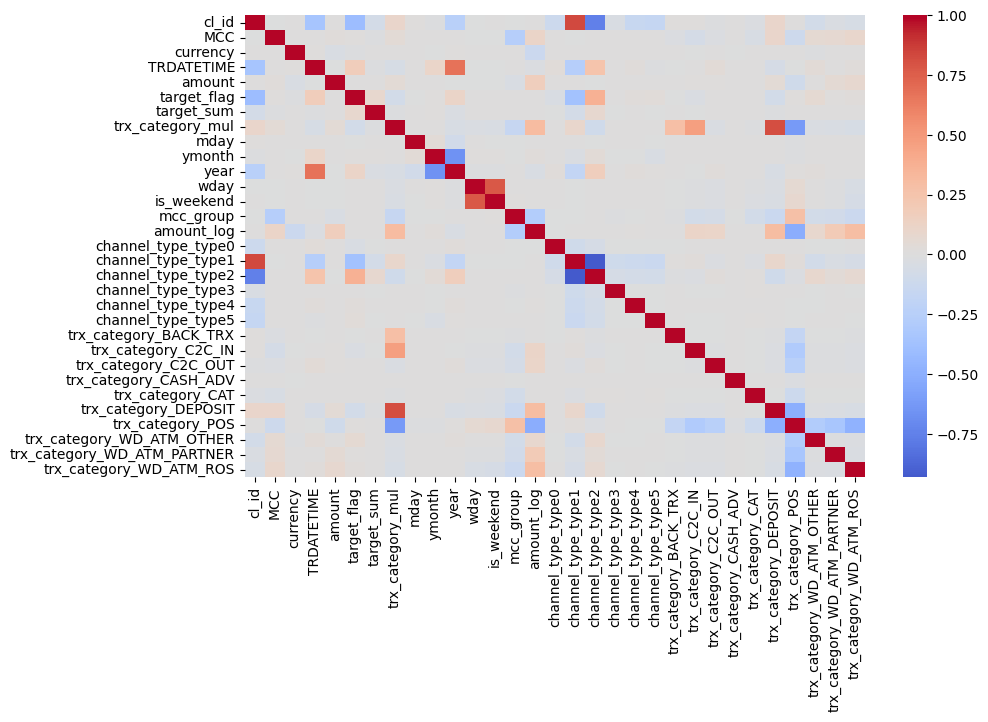

In [350]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.show()

In [351]:
corr_with_target_flag = corr_matrix["target_flag"]
print(corr_with_target_flag.sort_values(ascending=False))

target_flag                    1.000
channel_type_type2             0.367
TRDATETIME                     0.171
year                           0.116
target_sum                     0.081
trx_category_WD_ATM_OTHER      0.061
channel_type_type5             0.028
trx_category_WD_ATM_ROS        0.025
channel_type_type4             0.024
trx_category_WD_ATM_PARTNER    0.018
ymonth                         0.018
trx_category_POS               0.015
MCC                            0.013
trx_category_CAT               0.010
channel_type_type3             0.006
amount_log                     0.006
wday                           0.005
is_weekend                     0.005
trx_category_C2C_OUT           0.004
mcc_group                      0.001
trx_category_CASH_ADV         -0.002
amount                        -0.003
mday                          -0.009
trx_category_BACK_TRX         -0.010
currency                      -0.014
trx_category_C2C_IN           -0.028
channel_type_type0            -0.034
t

In [401]:
yearly_sum = df.groupby("year")["target_flag"].sum()
print(yearly_sum)
print(df["year"].value_counts())
df_sorted = df.sort_values(by = "target_flag", ascending=False)[["cl_id", "target_flag"]]
first_cl_id = None

for idx, flag in enumerate(df_sorted["target_flag"]):
    if flag != 1:
        first_cl_id = df.loc[idx, "cl_id"]
        break

print(first_cl_id)


year
2016     36343
2017    277625
2018      6135
Name: target_flag, dtype: int64
year
2017    411734
2016     70405
2018      8374
Name: count, dtype: int64
6322


In [425]:
y_pred = ((X_test["channel_type_type2"] == 1) &
          (X_test["channel_type_type1"] == 0) |
          (X_test["cl_id"] < 6322)
          ).astype(int)

In [357]:
from sklearn.metrics import accuracy_score

In [426]:
accuracy_score(y_test['target_flag'], y_pred)

0.7129877543254006